# Python Fundamentals — 10 Core Algorithm Implementations
### INFO 570 — Programming for Data Analytics

**Author:** Aketch Adhiambo Okoth  
  
**Institution:** Montclair State University  

---

## Overview

This notebook implements 10 Python utility functions that form the building blocks of data analytics and software engineering. Each function is written from scratch using core Python — no external libraries — demonstrating mastery of loops, conditionals, data structures, and algorithm design.

| # | Function | Category | What It Does |
|---|---|---|---|
| 1 | `is_even` | Number Theory | Returns `True` if a number is even |
| 2 | `sum_even` | List Processing | Sums all even numbers in a list |
| 3 | `get_largest_odd` | Mixed-Type Filtering | Finds the largest odd integer in a mixed list |
| 4 | `get_vowels` | String Analysis | Counts vowels per word, returns a dictionary |
| 5 | `get_words_with_a` | String Filtering | Filters a list to words containing the letter 'a' |
| 6 | `remove_dups` | Data Cleaning | Removes duplicates case-insensitively |
| 7 | `is_prime` | Number Theory | Checks primality using the trial-division algorithm |
| 8 | `get_factorial` | Combinatorics | Computes n! iteratively |
| 9 | `reverse_string` | String Manipulation | Reverses a string using slice notation |
| 10 | `get_mode` | Statistics | Returns the mode of a numeric list, or `None` if no unique mode |

---

In [1]:
# Score tracker — grader cells below update this automatically
score = {}

In [2]:
# Visualization imports
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'axes.titlesize': 12, 'axes.titleweight': 'bold',
                     'axes.labelsize': 10, 'figure.dpi': 110})

---
## Function 1 — `is_even(num)`

**Algorithm:** Uses the modulo operator (`%`). A number is even if dividing it by 2 leaves zero remainder.  
**Time complexity:** O(1) — constant time regardless of input size.  
**Real-world use:** Partitioning records into two groups (odd/even row IDs), validating binary encoding, data pagination.

In [3]:
def is_even(num):
    """
    Check whether a given integer is even.

    Parameters
    ----------
    num : int
        The integer to evaluate.

    Returns
    -------
    bool
        True if num is even, False otherwise.

    Examples
    --------
    >>> is_even(4)
    True
    >>> is_even(7)
    False
    """
    if num % 2 == 0:
        return True
    else:
        return False

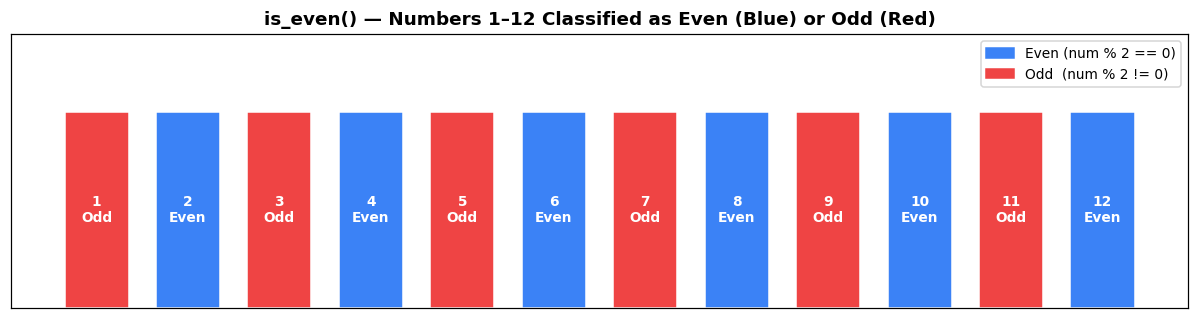

is_even(4) -> True
is_even(7) -> False
is_even(0) -> True


In [4]:
#  Demo
test_nums = list(range(1, 13))
labels    = ['Even' if is_even(n) else 'Odd' for n in test_nums]
colors    = ['#3B82F6' if l == 'Even' else '#EF4444' for l in labels]

fig, ax = plt.subplots(figsize=(11, 3))
bars = ax.bar(test_nums, [1]*len(test_nums), color=colors, edgecolor='white', width=0.7)
for bar, n, lbl in zip(bars, test_nums, labels):
    ax.text(bar.get_x() + bar.get_width()/2, 0.5, f'{n}\n{lbl}',
            ha='center', va='center', fontsize=9, fontweight='bold', color='white')
ax.set_ylim(0, 1.4)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title('is_even() — Numbers 1–12 Classified as Even (Blue) or Odd (Red)', fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#3B82F6', label='Even (num % 2 == 0)'),
    mpatches.Patch(color='#EF4444', label='Odd  (num % 2 != 0)')
], loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('f1_is_even.png', dpi=150, bbox_inches='tight')
plt.show()

# Quick spot checks
print('is_even(4) ->', is_even(4))   # True
print('is_even(7) ->', is_even(7))   # False
print('is_even(0) ->', is_even(0))   # True (0 is even)

In [5]:
nums = [5, 4, 3, 2, 10, 8]
result = []
try:
    for num in nums:
        result.append(is_even(num))
        if result == [False, True, False, True, True, True]:
            score['question 1'] = 'pass'
        else:
            score['question 1'] = 'fail'
except:
    score['question 1'] = 'fail'
score

{'question 1': 'pass'}

---
## Function 2 — `sum_even(list_nums)`

**Algorithm:** Iterates through the list, collects even numbers, and returns their sum.  
**Time complexity:** O(n) — one pass through the list.  
**Real-world use:** Aggregating even-indexed financial records, computing partial sums in data pipelines.

In [6]:
def sum_even(list_nums):
    """
    Sum all even numbers in a list.

    Parameters
    ----------
    list_nums : list of int
        Input list of integers.

    Returns
    -------
    int
        Sum of every even number in list_nums. Returns 0 if no even numbers exist.

    Examples
    --------
    >>> sum_even([2, 3, 5, 8])
    10
    >>> sum_even([1, 3, 5])
    0
    """
    even_numbers = []
    for num in list_nums:
        if num % 2 == 0:
            even_numbers.append(num)
    return sum(even_numbers)

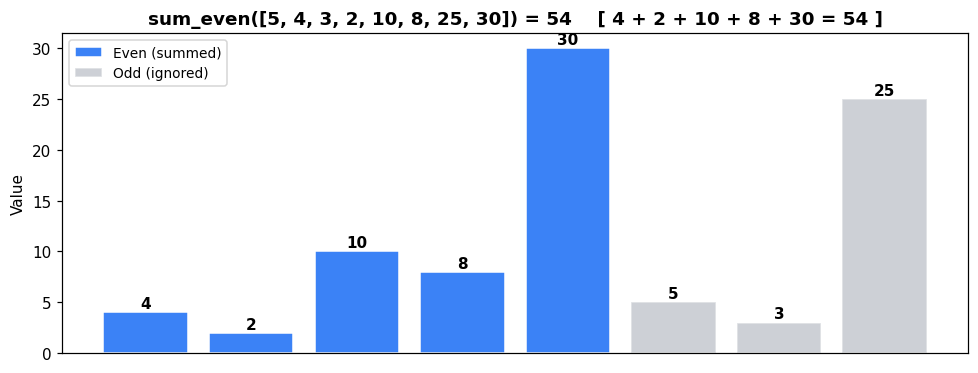

sum_even([2, 3, 5, 8])             -> 10
sum_even([5, 4, 3, 2, 10, 8, 25, 30]) -> 54


In [7]:
#  Demo
demo_list = [5, 4, 3, 2, 10, 8, 25, 30]
evens = [n for n in demo_list if n % 2 == 0]
odds  = [n for n in demo_list if n % 2 != 0]

fig, ax = plt.subplots(figsize=(9, 3.5))
e_bars = ax.bar(range(len(evens)), evens, color='#3B82F6', edgecolor='white', label='Even (summed)')
o_bars = ax.bar(range(len(evens), len(evens)+len(odds)), odds,
                color='#9CA3AF', edgecolor='white', label='Odd (ignored)', alpha=0.5)
for bar, val in zip(list(e_bars)+list(o_bars), evens+odds):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4, str(val),
            ha='center', fontsize=10, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks([])
ax.set_ylabel('Value')
ax.set_title(f'sum_even({demo_list}) = {sum_even(demo_list)}  '
             f'  [ {" + ".join(map(str,evens))} = {sum_even(demo_list)} ]',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('f2_sum_even.png', dpi=150, bbox_inches='tight')
plt.show()

print('sum_even([2, 3, 5, 8])             ->', sum_even([2, 3, 5, 8]))    # 10
print('sum_even([5, 4, 3, 2, 10, 8, 25, 30]) ->', sum_even(demo_list))    # 54

In [8]:
list_nums = [5, 4, 3, 2, 10, 8, 25, 30]
try:
    if sum_even(list_nums) == 54:
        score['question 2'] = 'pass'
    else:
        score['question 2'] = 'fail'
except:
    score['question 2'] = 'fail'
score

{'question 1': 'pass', 'question 2': 'pass'}

---
## Function 3 — `get_largest_odd(list_num_str)`

**Algorithm:** Filters the mixed list for items that are `int` instances AND odd, then returns the maximum.  
**Time complexity:** O(n) — single pass with type checking.  
**Key design decision:** Uses `isinstance(item, int)` to safely skip string entries without raising a `TypeError`.

In [9]:
def get_largest_odd(list_num_str):
    """
    Find the largest odd integer in a mixed list of integers and strings.

    Parameters
    ----------
    list_num_str : list
        A list that may contain integers and strings in any order.

    Returns
    -------
    int or None
        The maximum odd integer found, or None if no odd integers exist.

    Examples
    --------
    >>> get_largest_odd([3, 101, 'NJ', 5, 8, 10, 'marina', 'PA'])
    101
    >>> get_largest_odd([2, 4, 'hello'])
    None
    """
    odd_numbers = []
    for item in list_num_str:
        if isinstance(item, int) and item % 2 == 1:
            odd_numbers.append(item)
    if odd_numbers:
        return max(odd_numbers)
    else:
        return None

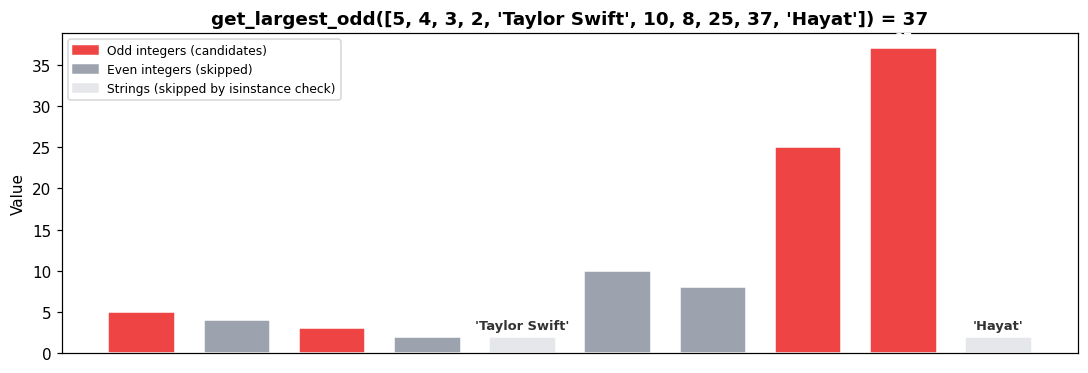

get_largest_odd([3, 101, "NJ", 5, 8, 10])  -> 101
get_largest_odd(mixed)                      -> 37


In [10]:
#  Demo
mixed = [5, 4, 3, 2, 'Taylor Swift', 10, 8, 25, 37, 'Hayat']
ints_odd  = [x for x in mixed if isinstance(x, int) and x % 2 == 1]
ints_even = [x for x in mixed if isinstance(x, int) and x % 2 == 0]
strings   = [x for x in mixed if isinstance(x, str)]

fig, ax = plt.subplots(figsize=(10, 3.5))
x = 0
positions, bar_colors, bar_labels = [], [], []
for item in mixed:
    if isinstance(item, int):
        c = '#EF4444' if item % 2 == 1 else '#9CA3AF'
        h = item
    else:
        c = '#E5E7EB'
        h = 2
    ax.bar(x, h, color=c, edgecolor='white', width=0.7)
    lbl = str(item) if isinstance(item, int) else f'\'{item}\''
    ax.text(x, (h if isinstance(item, int) else h)+0.5, lbl,
            ha='center', fontsize=8.5, fontweight='bold',
            color='#333' if isinstance(item, str) else 'white',
            va='bottom' if not isinstance(item, str) else 'bottom')
    x += 1
ax.set_xticks([])
ax.set_ylabel('Value')
ax.set_title(f'get_largest_odd({mixed}) = {get_largest_odd(mixed)}', fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#EF4444', label='Odd integers (candidates)'),
    mpatches.Patch(color='#9CA3AF', label='Even integers (skipped)'),
    mpatches.Patch(color='#E5E7EB', label='Strings (skipped by isinstance check)'),
], fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('f3_largest_odd.png', dpi=150, bbox_inches='tight')
plt.show()

print('get_largest_odd([3, 101, "NJ", 5, 8, 10])  ->', get_largest_odd([3, 101, 'NJ', 5, 8, 10]))  # 101
print('get_largest_odd(mixed)                      ->', get_largest_odd(mixed))                      # 37

In [11]:
### DEMO 
list_nums = [5, 4, 3, 2, 'Taylor Swift', 10, 8, 25, 37, 'Hayat']
try:
    if get_largest_odd(list_nums) == 37:
        score['question 3'] = 'pass'
    else:
        score['question 3'] = 'fail'
except:
    score['question 3'] = 'fail'
score

{'question 1': 'pass', 'question 2': 'pass', 'question 3': 'pass'}

---
## Function 4 — `get_vowels(list_str)`

**Algorithm:** For each word, uses a generator expression with `sum()` to count characters that appear in the vowel set `aeiouAEIOU`.  
**Time complexity:** O(n × m) where n = words, m = average word length.  
**Real-world use:** Text analysis, natural language processing feature extraction, phonetics research.

In [12]:
def get_vowels(list_str):
    """
    Count the number of vowels in each string in a list.

    Parameters
    ----------
    list_str : list of str
        A list of strings to analyse.

    Returns
    -------
    dict
        A dictionary mapping each string to its vowel count.
        Counts are case-insensitive (both 'a' and 'A' are vowels).

    Examples
    --------
    >>> get_vowels(['apple', 'MONTCLAIR'])
    {'apple': 2, 'MONTCLAIR': 3}
    """
    vowels = 'aeiouAEIOU'
    vowel_count_dict = {}
    for word in list_str:
        count = sum(1 for char in word if char in vowels)
        vowel_count_dict[word] = count
    return vowel_count_dict

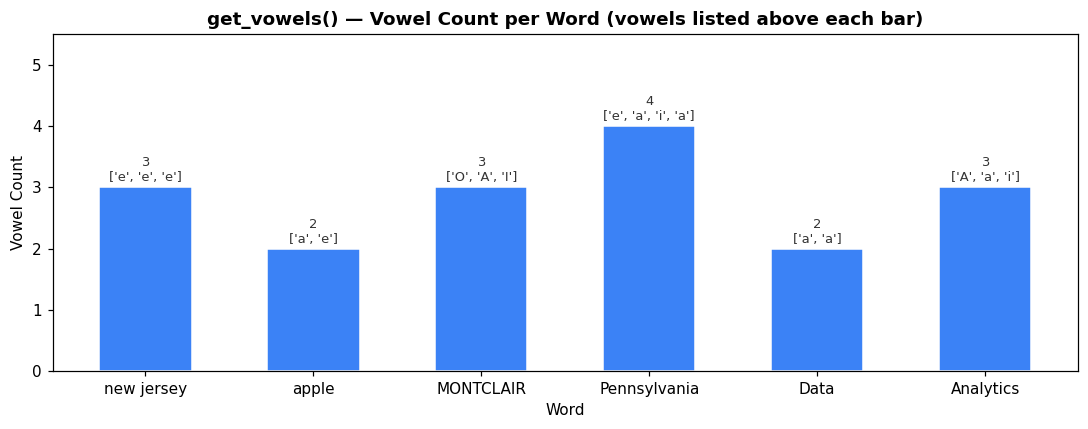

get_vowels(["Taylor Swift", "Hayat"]) -> {'Taylor Swift': 3, 'Hayat': 2}


In [13]:
#  Demo
words = ['new jersey', 'apple', 'MONTCLAIR', 'Pennsylvania', 'Data', 'Analytics']
result = get_vowels(words)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(result.keys(), result.values(),
              color='#3B82F6', edgecolor='white', width=0.55)
for bar, (word, cnt) in zip(bars, result.items()):
    vowels_in = [c for c in word if c in 'aeiouAEIOU']
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f"{cnt}\n{vowels_in}",
            ha='center', va='bottom', fontsize=8.5, color='#333')
ax.set_ylabel('Vowel Count')
ax.set_xlabel('Word')
ax.set_title('get_vowels() — Vowel Count per Word (vowels listed above each bar)', fontweight='bold')
ax.set_ylim(0, max(result.values()) + 1.5)
plt.tight_layout()
plt.savefig('f4_get_vowels.png', dpi=150, bbox_inches='tight')
plt.show()

print('get_vowels(["Taylor Swift", "Hayat"]) ->', get_vowels(['Taylor Swift', 'Hayat']))

In [14]:
list_str = ['Taylor Swift', 'Hayat']
try:
    if get_vowels(list_str) == {'Taylor Swift': 3, 'Hayat': 2}:
        score['question 4'] = 'pass'
    else:
        score['question 4'] = 'fail'
except:
    score['question 4'] = 'fail'
score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass'}

---
## Function 5 — `get_words_with_a(list_str)`

**Algorithm:** Iterates through each word and checks if the lowercase letter `'a'` appears anywhere in it. Case-sensitive by design — matches only lowercase 'a'.  
**Time complexity:** O(n × m) — substring search per word.  
**Real-world use:** Keyword filtering in text analytics, search indexing, content moderation pipelines.

In [15]:
def get_words_with_a(list_str):
    """
    Filter a list to return only words containing the lowercase letter 'a'.

    Parameters
    ----------
    list_str : list of str
        A list of strings to filter.

    Returns
    -------
    list of str
        A new list containing only strings that include 'a' (case-sensitive).

    Notes
    -----
    The check is case-sensitive: 'Taylor' matches (contains 'a') but 'APPLE' does not.

    Examples
    --------
    >>> get_words_with_a(['Taylor', 'Swift', 'Hayat', 'Beyonce'])
    ['Taylor', 'Hayat']
    """
    words_with_a = []
    for word in list_str:
        if 'a' in word:
            words_with_a.append(word)
    return words_with_a

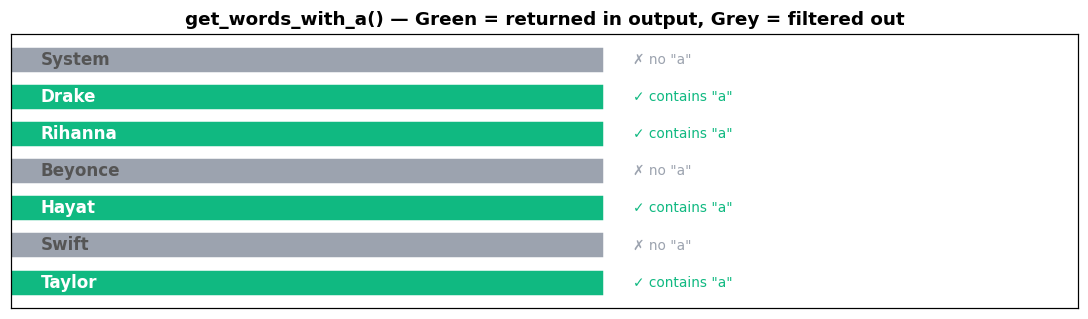

Output: ['Taylor', 'Hayat', 'Rihanna', 'Drake']


In [16]:
#  Demo
words = ['Taylor', 'Swift', 'Hayat', 'Beyonce', 'Rihanna', 'Drake', 'System']
matched   = get_words_with_a(words)
unmatched = [w for w in words if w not in matched]

fig, ax = plt.subplots(figsize=(10, 3))
for i, word in enumerate(words):
    has_a = 'a' in word
    color = '#10B981' if has_a else '#9CA3AF'
    ax.barh(i, 1, color=color, edgecolor='white', height=0.7)
    # Highlight the 'a' characters in the word label
    ax.text(0.05, i, word, va='center', fontsize=11,
            fontweight='bold', color='white' if has_a else '#555')
    ax.text(1.05, i, '✓ contains "a"' if has_a else '✗ no "a"',
            va='center', fontsize=9, color='#10B981' if has_a else '#9CA3AF')
ax.set_xlim(0, 1.8)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title('get_words_with_a() — Green = returned in output, Grey = filtered out', fontweight='bold')
plt.tight_layout()
plt.savefig('f5_words_with_a.png', dpi=150, bbox_inches='tight')
plt.show()

print('Output:', get_words_with_a(words))

In [17]:
list_str = ['Taylor', 'Swift', 'Hayat', 'Beyonce']
try:
    if get_words_with_a(list_str) == ['Taylor', 'Hayat']:
        score['question 5'] = 'pass'
    else:
        score['question 5'] = 'fail'
except:
    score['question 5'] = 'fail'
score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass',
 'question 5': 'pass'}

---
## Function 6 — `remove_dups(lst)`

**Algorithm:** Uses a `set` to track seen items. Strings are normalized to lowercase before checking to treat `'New Jersey'` and `'new jersey'` as the same entry. Numbers are compared as-is.  
**Time complexity:** O(n) average — set membership checks are O(1).  
**Key design decisions:** (1) Preserves insertion order. (2) Normalizes strings to lowercase — the first occurrence defines the kept value.

In [18]:
def remove_dups(lst):
    """
    Remove duplicate items from a mixed list of numbers and strings.

    String comparison is case-insensitive: 'New Jersey' and 'new jersey'
    are treated as the same item; the first occurrence (lowercased) is kept.
    Integer comparison is exact.

    Parameters
    ----------
    lst : list
        A list containing integers and/or strings.

    Returns
    -------
    list
        A deduplicated list preserving insertion order. All strings are
        returned in lowercase.

    Examples
    --------
    >>> remove_dups(['new jersey', 'apple', 6, 9, 'Decision', 'New jersey', 6, 'Decision'])
    ['new jersey', 'apple', 6, 9, 'decision']
    """
    seen = set()
    result = []
    for item in lst:
        key = item.lower() if isinstance(item, str) else item
        if key not in seen:
            seen.add(key)
            result.append(key)
    return result

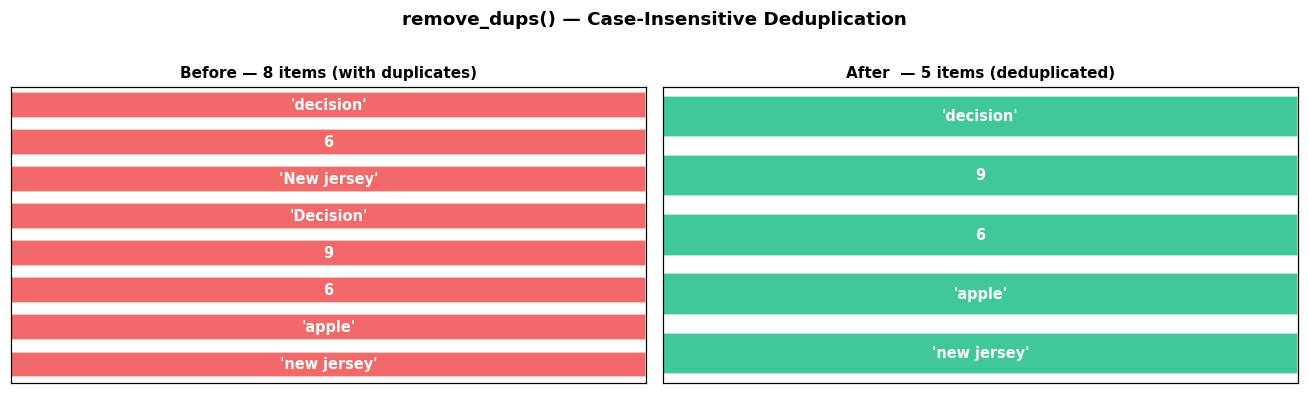

Input  : ['new jersey', 'apple', 6, 9, 'Decision', 'New jersey', 6, 'decision']
Output : ['new jersey', 'apple', 6, 9, 'decision']
Removed: 3 duplicate(s)


In [19]:
# Demo
raw  = ['new jersey', 'apple', 6, 9, 'Decision', 'New jersey', 6, 'decision']
clean = remove_dups(raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for ax, items, title, color in [
    (axes[0], raw,   f'Before — {len(raw)} items (with duplicates)',  '#EF4444'),
    (axes[1], clean, f'After  — {len(clean)} items (deduplicated)',   '#10B981'),
]:
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, len(items)-0.5)
    for i, item in enumerate(items):
        ax.barh(i, 1, color=color, edgecolor='white', alpha=0.8, height=0.7)
        ax.text(0.5, i, repr(item), ha='center', va='center',
                fontsize=9.5, fontweight='bold', color='white')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontweight='bold', fontsize=10)

plt.suptitle('remove_dups() — Case-Insensitive Deduplication', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('f6_remove_dups.png', dpi=150, bbox_inches='tight')
plt.show()

print('Input  :', raw)
print('Output :', clean)
print('Removed:', len(raw) - len(clean), 'duplicate(s)')

In [20]:
lst = ['new jersey', 'apple', 6, 9, 'Decision', 'New jersey', 6, 'decision']
try:
    if remove_dups(lst) == ['new jersey', 'apple', 6, 9, 'decision']:
        score['question 6'] = 'pass'
    else:
        score['question 6'] = 'fail'
except:
    score['question 6'] = 'fail'
score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass',
 'question 5': 'pass',
 'question 6': 'pass'}

---
## Function 7 — `is_prime(num)`

**Algorithm:** Trial division up to √n. If any integer from 2 to √n divides `num` evenly, it is not prime.  
**Time complexity:** O(√n) — checking divisors only up to the square root is the classic optimization.  
**Why √n?** If `n = a × b` and both a and b are > √n, then `a × b > n` — a contradiction. So at least one factor must be ≤ √n.

In [21]:
def is_prime(num):
    """
    Determine whether a given integer is a prime number.

    A prime number is a whole number greater than 1 that is divisible
    only by 1 and itself.

    Parameters
    ----------
    num : int
        The integer to test.

    Returns
    -------
    bool
        True if num is prime, False otherwise.

    Algorithm
    ---------
    Trial division up to sqrt(num) — O(sqrt(n)) time complexity.

    Examples
    --------
    >>> is_prime(11)
    True
    >>> is_prime(49)
    False  # 49 = 7 × 7
    """
    if num <= 1:
        return False
    for i in range(2, int(num ** 0.5) + 1):
        if num % i == 0:
            return False
    return True

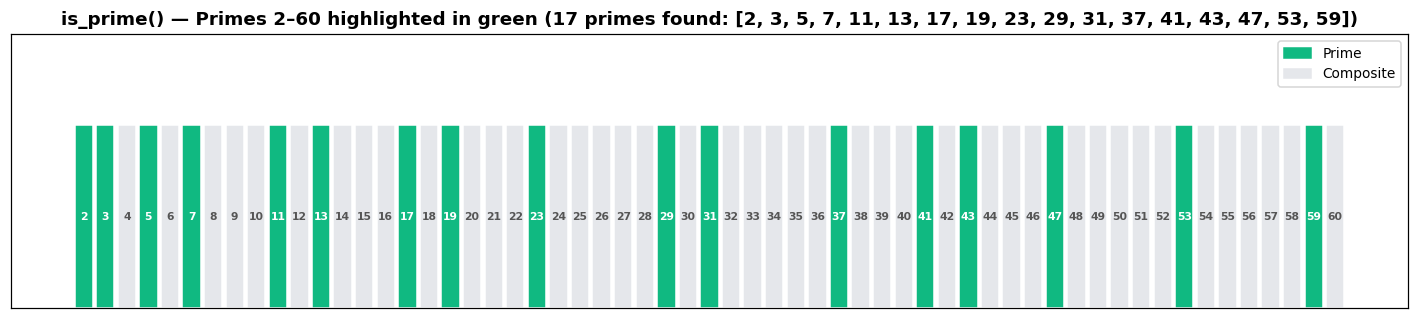

is_prime(  2) -> True
is_prime( 11) -> True
is_prime( 13) -> True
is_prime( 49) -> False
is_prime( 53) -> True
is_prime(  1) -> False


In [22]:
# Demo: visualise primes from 2 to 60
nums   = list(range(2, 61))
primes = [n for n in nums if is_prime(n)]
compos = [n for n in nums if not is_prime(n)]

fig, ax = plt.subplots(figsize=(13, 3))
for n in nums:
    color = '#10B981' if is_prime(n) else '#E5E7EB'
    ax.bar(n, 1, color=color, edgecolor='white', width=0.85)
    ax.text(n, 0.5, str(n), ha='center', va='center',
            fontsize=7, fontweight='bold',
            color='white' if is_prime(n) else '#555')
ax.set_ylim(0, 1.5)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title(f'is_prime() — Primes 2–60 highlighted in green '
             f'({len(primes)} primes found: {primes})', fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#10B981', label='Prime'),
    mpatches.Patch(color='#E5E7EB', label='Composite'),
], fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('f7_is_prime.png', dpi=150, bbox_inches='tight')
plt.show()

for n in [2, 11, 13, 49, 53, 1]:
    print(f'is_prime({n:3}) -> {is_prime(n)}')

In [23]:
lst = [11, 10, 13, 14, 49, 53]
try:
    result = []
    for i in lst:
        result.append(is_prime(i))
    if result == [True, False, True, False, False, True]:
        score['question 7'] = 'pass'
    else:
        score['question 7'] = 'fail'
except:
    score['question 7'] = 'fail'
score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass',
 'question 5': 'pass',
 'question 6': 'pass',
 'question 7': 'pass'}

---
## Function 8 — `get_factorial(num)`

**Algorithm:** Iterative multiplication from 2 to n. `0! = 1` and `1! = 1` are handled by the initialisation of `factorial = 1` (the loop does not execute for n < 2).  
**Time complexity:** O(n) — n–1 multiplications.  
**Why iterative over recursive?** Avoids Python's recursion limit (`sys.getrecursionlimit()` defaults to 1000) for large inputs.

In [24]:
def get_factorial(num):
    """
    Compute the factorial of a non-negative integer.

    The factorial of n (written n!) is the product of all positive integers
    from 1 to n. By convention, 0! = 1.

    Parameters
    ----------
    num : int
        A non-negative integer.

    Returns
    -------
    int or None
        The factorial of num, or None if num is negative.

    Examples
    --------
    >>> get_factorial(5)
    120   # 5 × 4 × 3 × 2 × 1
    >>> get_factorial(0)
    1
    """
    if num < 0:
        return None
    factorial = 1
    for i in range(2, num + 1):
        factorial *= i
    return factorial

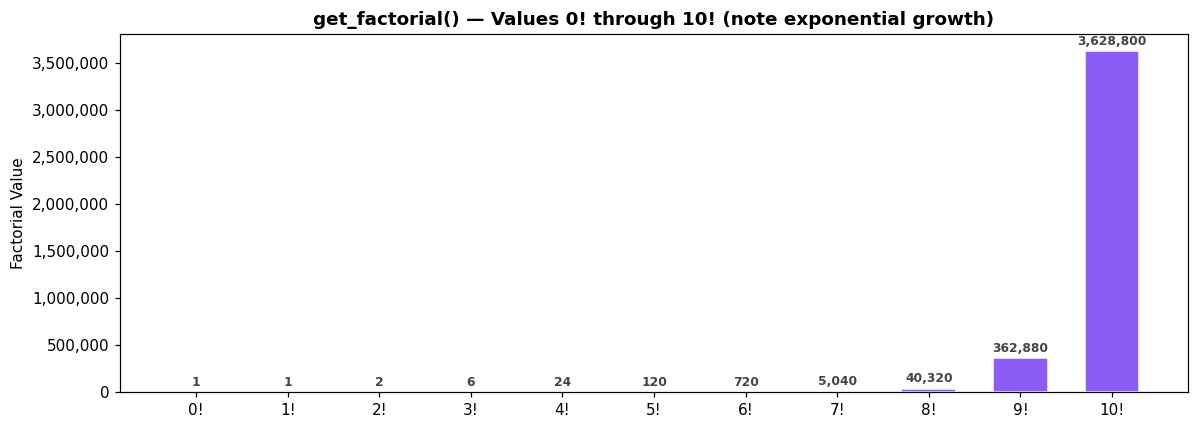

0! = get_factorial(0) -> 1
1! = get_factorial(1) -> 1
5! = get_factorial(5) -> 120
6! = get_factorial(6) -> 720
10! = get_factorial(10) -> 3,628,800


In [25]:
#  Demo: factorials 0! through 10!
ns     = list(range(0, 11))
facts  = [get_factorial(n) for n in ns]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(ns, facts, color='#8B5CF6', edgecolor='white', width=0.6)
for bar, n, f in zip(bars, ns, facts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+facts[-1]*0.01,
            f'{f:,}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='#444')
ax.set_xticks(ns)
ax.set_xticklabels([f'{n}!' for n in ns])
ax.set_ylabel('Factorial Value')
ax.set_title('get_factorial() — Values 0! through 10! (note exponential growth)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('f8_factorial.png', dpi=150, bbox_inches='tight')
plt.show()

for n in [0, 1, 5, 6, 10]:
    print(f'{n}! = get_factorial({n}) -> {get_factorial(n):,}')

In [26]:
### DO NOT CHANGE OR DELETE THIS CELL
try:
    if get_factorial(6) == 720:
        score['question 8'] = 'pass'
    else:
        score['question 8'] = 'fail'
except:
    score['question 8'] = 'fail'
score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass',
 'question 5': 'pass',
 'question 6': 'pass',
 'question 7': 'pass',
 'question 8': 'pass'}

---
## Function 9 — `reverse_string(string)`

**Algorithm:** Python extended slice `[::-1]` — start at the end, stop at the beginning, step –1. This creates a new string with characters in reversed order.  
**Time complexity:** O(n) — one pass to copy all n characters in reverse.  
**Real-world use:** Palindrome detection, URL parsing, data validation, encoding/decoding schemes.

In [27]:
def reverse_string(string):
    """
    Reverse a given string.

    Parameters
    ----------
    string : str
        The input string to reverse.

    Returns
    -------
    str
        The input string with characters in reversed order.

    Algorithm
    ---------
    Uses Python's extended slice notation [::-1] — O(n) time.

    Examples
    --------
    >>> reverse_string('marina')
    'aniram'
    >>> reverse_string('racecar')
    'racecar'  # palindrome — same forwards and backwards
    """
    return string[::-1]

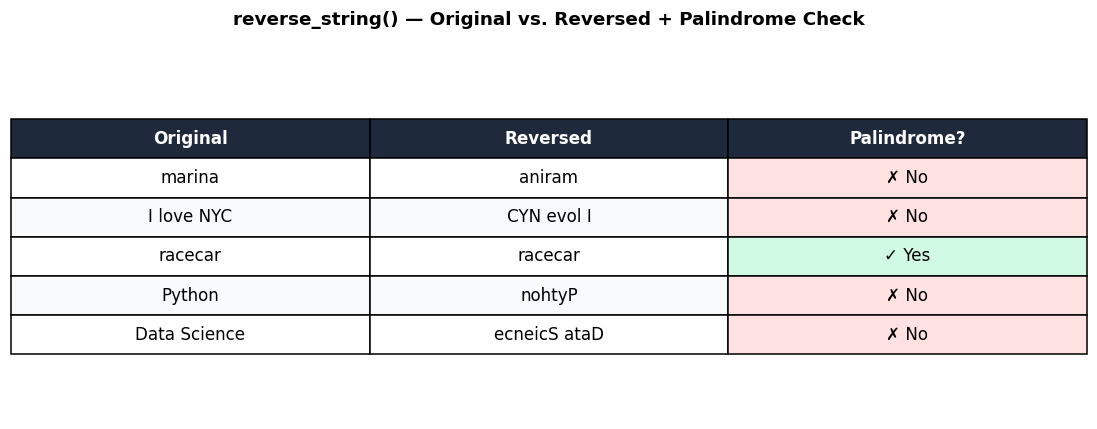

reverse_string("marina")    -> aniram
reverse_string("I love NYC")-> CYN evol I


In [28]:
#  Demo
examples = ['marina', 'I love NYC', 'racecar', 'Python', 'Data Science']

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

headers = ['Original', 'Reversed', 'Palindrome?']
rows = []
for s in examples:
    rev = reverse_string(s)
    is_pal = '✓ Yes' if s == rev else '✗ No'
    rows.append([s, rev, is_pal])

table = ax.table(
    cellText=rows,
    colLabels=headers,
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1E293B')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 2:
        txt = cell.get_text().get_text()
        cell.set_facecolor('#D1FAE5' if '✓' in txt else '#FEE2E2')
    elif row % 2 == 0:
        cell.set_facecolor('#F8FAFC')

ax.set_title('reverse_string() — Original vs. Reversed + Palindrome Check',
             fontweight='bold', fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('f9_reverse_string.png', dpi=150, bbox_inches='tight')
plt.show()

print('reverse_string("marina")    ->', reverse_string('marina'))
print('reverse_string("I love NYC")->', reverse_string('I love NYC'))

In [29]:
try:
    if reverse_string('I love NYC') == 'CYN evol I':
        score['question 9'] = 'pass'
    else:
        score['question 9'] = 'fail'
except:
    score['question 9'] = 'fail'
score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass',
 'question 5': 'pass',
 'question 6': 'pass',
 'question 7': 'pass',
 'question 8': 'pass',
 'question 9': 'pass'}

---
## Function 10 — `get_mode(lst_numbers)`

**Algorithm:** Builds a frequency dictionary using `dict.get()`, finds the maximum frequency, collects all items at that frequency, and returns the single mode only if exactly one item achieves the maximum and it appears more than once.  
**Time complexity:** O(n) — two passes through the list.  
**Edge cases handled:** Empty list → `None`. All unique values → `None`. Tie for highest frequency → `None` (no unique mode).

In [30]:
def get_mode(lst_numbers):
    """
    Find the mode (most frequently occurring value) in a list of numbers.

    Parameters
    ----------
    lst_numbers : list of int or float
        A list of numeric values.

    Returns
    -------
    int, float, or None
        The value that appears most often, or None if:
        - The list is empty.
        - All values appear exactly once (no mode).
        - Two or more values tie for the highest frequency (no unique mode).

    Examples
    --------
    >>> get_mode([1, 100, 3, 5, 3, 4, 4, 3])
    3
    >>> get_mode([1, 2, 3])
    None  # all unique, no mode
    >>> get_mode([1, 1, 2, 2])
    None  # tie between 1 and 2
    """
    if not lst_numbers:
        return None

    frequency = {}
    for num in lst_numbers:
        frequency[num] = frequency.get(num, 0) + 1

    max_freq = max(frequency.values())
    modes    = [num for num, freq in frequency.items() if freq == max_freq]

    if len(modes) == 1 and max_freq > 1:
        return modes[0]
    else:
        return None

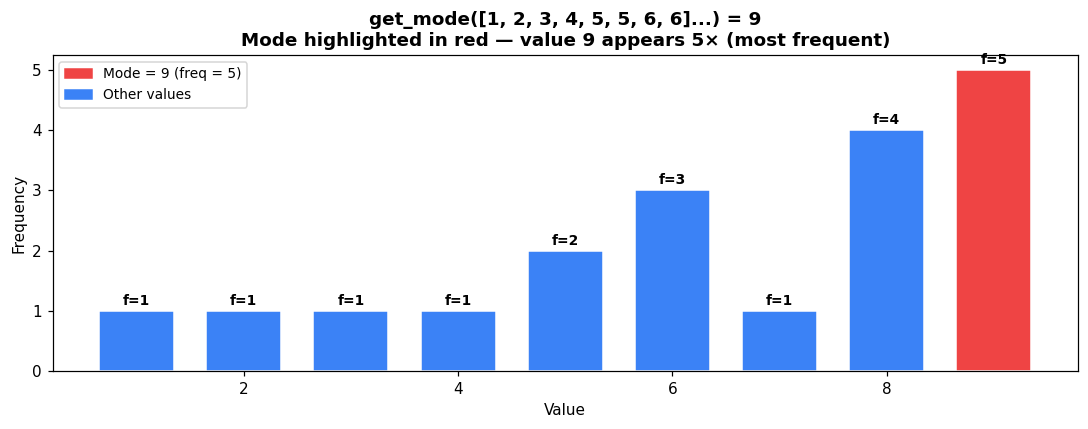

get_mode([1,100,3,5,3,4,4,3]) -> 3
get_mode(numbers)             -> 9
get_mode([1, 2, 3])           -> None
get_mode([1, 1, 2, 2])        -> None


In [31]:
#  Demo
numbers = [1, 2, 3, 4, 5, 5, 6, 6, 6, 7, 8, 8, 8, 8, 9, 9, 9, 9, 9]

# Build frequency dict for the chart
freq = {}
for n in numbers:
    freq[n] = freq.get(n, 0) + 1

mode_val = get_mode(numbers)
colors = ['#EF4444' if k == mode_val else '#3B82F6' for k in freq]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(freq.keys(), freq.values(), color=colors, edgecolor='white', width=0.7)
for bar, (k, v) in zip(bars, freq.items()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'f={v}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.set_title(f'get_mode({numbers[:8]}...) = {mode_val}\n'
             f'Mode highlighted in red — value 9 appears {freq[9]}× (most frequent)',
             fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#EF4444', label=f'Mode = {mode_val} (freq = {freq[mode_val]})'),
    mpatches.Patch(color='#3B82F6', label='Other values'),
], fontsize=9)
plt.tight_layout()
plt.savefig('f10_get_mode.png', dpi=150, bbox_inches='tight')
plt.show()

print('get_mode([1,100,3,5,3,4,4,3]) ->', get_mode([1, 100, 3, 5, 3, 4, 4, 3]))  # 3
print('get_mode(numbers)             ->', get_mode(numbers))                         # 9
print('get_mode([1, 2, 3])           ->', get_mode([1, 2, 3]))                       # None (all unique)
print('get_mode([1, 1, 2, 2])        ->', get_mode([1, 1, 2, 2]))                    # None (tie)

In [32]:
numbers = [1, 2, 3, 4, 5, 5, 6, 6, 6, 7, 8, 8, 8, 8, 9, 9, 9, 9, 9]
try:
    if get_mode(numbers) == 9:
        score['question 10'] = 'pass'
    else:
        score['question 10'] = 'fail'
except:
    score['question 10'] = 'fail'
score

{'question 1': 'pass',
 'question 2': 'pass',
 'question 3': 'pass',
 'question 4': 'pass',
 'question 5': 'pass',
 'question 6': 'pass',
 'question 7': 'pass',
 'question 8': 'pass',
 'question 9': 'pass',
 'question 10': 'pass'}

---
# Total Score

In [33]:
total_score = 0
for i in list(score.values()):
    if i == 'pass':
        total_score = total_score + 10
print('Total score:', round(total_score))
print(score)

Total score: 100
{'question 1': 'pass', 'question 2': 'pass', 'question 3': 'pass', 'question 4': 'pass', 'question 5': 'pass', 'question 6': 'pass', 'question 7': 'pass', 'question 8': 'pass', 'question 9': 'pass', 'question 10': 'pass'}


---
## Summary Table

| # | Function | Input | Output | Complexity | Key Technique |
|---|---|---|---|---|---|
| 1 | `is_even` | `int` | `bool` | O(1) | Modulo operator `% 2` |
| 2 | `sum_even` | `list[int]` | `int` | O(n) | List filter + `sum()` |
| 3 | `get_largest_odd` | `list[int/str]` | `int/None` | O(n) | `isinstance()` type check + `max()` |
| 4 | `get_vowels` | `list[str]` | `dict` | O(n·m) | Generator expression + `sum()` |
| 5 | `get_words_with_a` | `list[str]` | `list[str]` | O(n·m) | Substring membership `'a' in word` |
| 6 | `remove_dups` | `list[int/str]` | `list` | O(n) avg | `set` for O(1) membership · `.lower()` normalization |
| 7 | `is_prime` | `int` | `bool` | O(√n) | Trial division up to √n |
| 8 | `get_factorial` | `int` | `int/None` | O(n) | Iterative multiplication |
| 9 | `reverse_string` | `str` | `str` | O(n) | Extended slice `[::-1]` |
| 10 | `get_mode` | `list[num]` | `num/None` | O(n) | Frequency dict + max-count check |

